# Integrator Comparison

This notebook runs the same Earth-Moon simulation with three integrators — RK4, Leapfrog, and RK45 — and compares their energy conservation over time.

In [1]:
import orbit
import numpy as np
import matplotlib.pyplot as plt

print('orbit version:', orbit.__version__)

orbit version: 2.0.0-dev


In [2]:
STEPS = 30 * 24 * 60   # 30 days at 1-minute timestep
DT    = 60.0

results = {
    'RK4':      orbit.simulate('../systems/earth_moon_horizons.json', STEPS, DT, orbit.Integrator.RK4),
    'Leapfrog': orbit.simulate('../systems/earth_moon_horizons.json', STEPS, DT, orbit.Integrator.Leapfrog),
    'RK45':     orbit.simulate('../systems/earth_moon_horizons.json', STEPS, DT, orbit.Integrator.RK45),
}

for name, r in results.items():
    E = r.energies_numpy()
    drift = abs((E[-1] - E[0]) / E[0])
    print(f'{name:10s}  energy drift: {drift:.3e}')


RK4         energy drift: 9.026e-15
Leapfrog    energy drift: 1.470e-13
RK45        energy drift: 9.026e-15


## Energy drift over time

Relative energy drift `(E(t) - E(0)) / |E(0)|` for each integrator over 30 days.

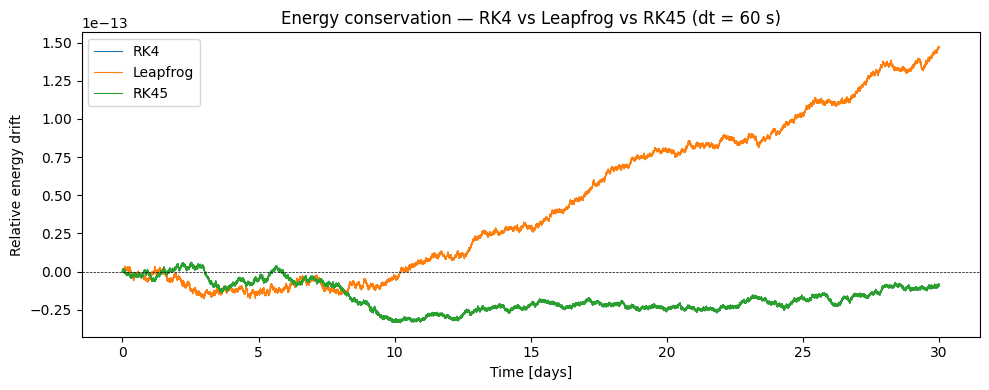

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))

for name, r in results.items():
    E = r.energies_numpy()
    t = np.arange(len(E)) / (24 * 60)   # steps → days
    drift = (E - E[0]) / abs(E[0])
    ax.plot(t, drift, lw=0.8, label=name)

ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('Time [days]')
ax.set_ylabel('Relative energy drift')
ax.set_title('Energy conservation — RK4 vs Leapfrog vs RK45 (dt = 60 s)')
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
print(f'{"Integrator":<12} {"Max |drift|":>14} {"Final drift":>14}')
print('-' * 42)
for name, r in results.items():
    E = r.energies_numpy()
    drift = (E - E[0]) / abs(E[0])
    print(f'{name:<12} {abs(drift).max():>14.3e} {drift[-1]:>14.3e}')

Integrator      Max |drift|    Final drift
------------------------------------------
RK4               3.356e-14     -9.026e-15
Leapfrog          1.477e-13      1.470e-13
RK45              3.356e-14     -9.026e-15
